# Exploratory Analysis — Sugar Tax Project

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


In [29]:
df = pd.read_csv("../data/raw/consumer_trends_soft_drinks.csv")
df.head()
df.columns

Index(['Title', '01.2.2 Non-alcoholic beverages Mineral water and soft drinks CP NSA £m'], dtype='str')

#### Rename columns

In [30]:

df = df.rename(columns={
    "Title": "quarter",
    "01.2.2 Non-alcoholic beverages Mineral water and soft drinks CP NSA £m": "soft_drinks_expenditure_m"
})


#### Check data types

In [31]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   quarter                    212 non-null    str  
 1   soft_drinks_expenditure_m  209 non-null    str  
dtypes: str(2)
memory usage: 3.4 KB


In [14]:
#convert expenditure to numeric
df["soft_drinks_expenditure_m"] = pd.to_numeric(df["soft_drinks_expenditure_m"], errors="coerce")

#convert quarter to datetime
df["quarter"] = pd.to_datetime(df["quarter"], errors="coerce")

C:\Users\YP153LM\AppData\Local\Temp\ipykernel_31336\272683502.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["quarter"] = pd.to_datetime(df["quarter"], errors="coerce")


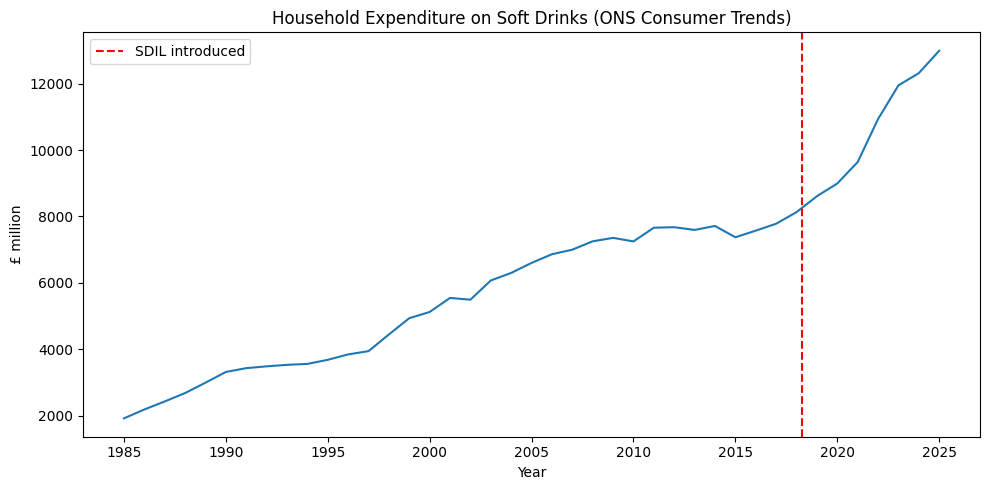

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(df["quarter"], df["soft_drinks_expenditure_m"])
plt.axvline(pd.Timestamp("2018-04-01"), color="red", linestyle="--", label="SDIL introduced")
plt.title("Household Expenditure on Soft Drinks (ONS Consumer Trends)")
plt.xlabel("Year")
plt.ylabel("£ million")
plt.legend()
plt.tight_layout()
plt.show()



This analysis treats the introduction of the UK Soft Drinks Industry Levy (April 2018) as a policy intervention in an interrupted time series framework.

The identifying assumption is that, absent the policy, household expenditure on soft drinks would have continued along its pre-2018 trend. Any discrete change in level or slope coinciding with the policy introduction is interpreted as evidence consistent with a policy effect.


In [32]:
# Convert quarter to datetime (ONS quarters usually like "2018 Q2")
df["quarter"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp()

# Convert expenditure to numeric
df["soft_drinks_expenditure_m"] = pd.to_numeric(
    df["soft_drinks_expenditure_m"], errors="coerce"
)

# Drop rows with missing expenditure
df = df.dropna(subset=["soft_drinks_expenditure_m"]).reset_index(drop=True)

DateParseError: Unknown datetime string format, unable to parse: CDID

In [33]:
df["quarter"].head(10)


0                 CDID
1    Source dataset ID
2              PreUnit
3                 Unit
4         Release date
5         Next release
6      Important notes
7                 1985
8                 1986
9                 1987
Name: quarter, dtype: str